### **MACHINE LEARNING**

**LAB 8**

In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_excel("C:\Sharan\CHRIST\T4\ML\Lab 8.xlsx")

Removing serial numbers if present

In [3]:
if "No" in df.columns:
    df = df.drop("No", axis=1)

print("Dataset:")
print(df)

Dataset:
     Outlook Temperature Humidity    Wind Play Tennis
0      Sunny         Hot     High    Weak          No
1      Sunny         Hot     High  Strong          No
2   Overcast         Hot     High    Weak         Yes
3       Rain        Mild     High    Weak         Yes
4       Rain        Cool   Normal    Weak         Yes
5       Rain        Cool   Normal  Strong          No
6   Overcast        Cool   Normal  Strong         Yes
7      Sunny        Mild     High    Weak          No
8      Sunny        Cool   Normal    Weak         Yes
9       Rain        Mild   Normal    Weak         Yes
10     Sunny        Mild   Normal  Strong         Yes
11  Overcast        Mild     High  Strong         Yes
12  Overcast         Hot   Normal    Weak         Yes
13      Rain        Mild     High  Strong          No
14     Sunny        Cool     High    Weak          No
15     Sunny        Cool     High  Strong          No
16     Sunny         Hot   Normal    Weak         Yes
17     Sunny       

Seperating features and targets

In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


Encoding categorical data

In [5]:
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

Splitting the dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.3,
    random_state=42
)

Training categorical Naive Bayes

In [7]:
nb = CategoricalNB()
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


Prediction & evaluation

In [8]:
y_pred = nb.predict(X_test)

In [9]:
print("\nCategorical Naive Bayes Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Categorical Naive Bayes Accuracy:
0.8

Confusion Matrix:
[[ 1  1]
 [ 2 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.92      0.85      0.88        13

    accuracy                           0.80        15
   macro avg       0.62      0.67      0.64        15
weighted avg       0.84      0.80      0.82        15



Predicting new weather conditions

In [10]:
new_data = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

new_encoded = encoder.transform(new_data)

prediction = nb.predict(new_encoded)
probability = nb.predict_proba(new_encoded)

print("\nPrediction for New Weather:")
print("Predicted Class:", label_encoder.inverse_transform(prediction)[0])
print("Class Probabilities:")

for cls, prob in zip(label_encoder.classes_, probability[0]):
    print(f"{cls}: {prob:.4f}")



Prediction for New Weather:
Predicted Class: No
Class Probabilities:
No: 0.9373
Yes: 0.0627


Decision tree

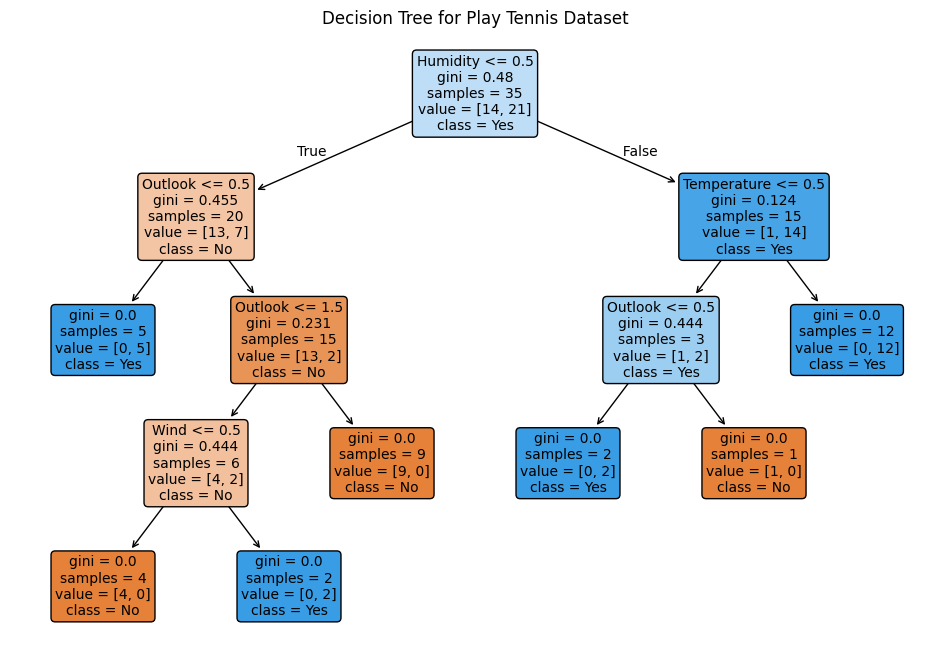

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Play Tennis Dataset")
plt.show()

In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))


Decision Tree Accuracy:
0.6


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.5333333333333333


In [16]:
print("\nPerformance Comparison")
print("---------------------------")
print("Categorical Naive Bayes :", accuracy_score(y_test, y_pred))
print("Decision Tree           :", accuracy_score(y_test, dt_pred))
print("Logistic Regression     :", accuracy_score(y_test, lr_pred))


Performance Comparison
---------------------------
Categorical Naive Bayes : 0.8
Decision Tree           : 0.6
Logistic Regression     : 0.5333333333333333


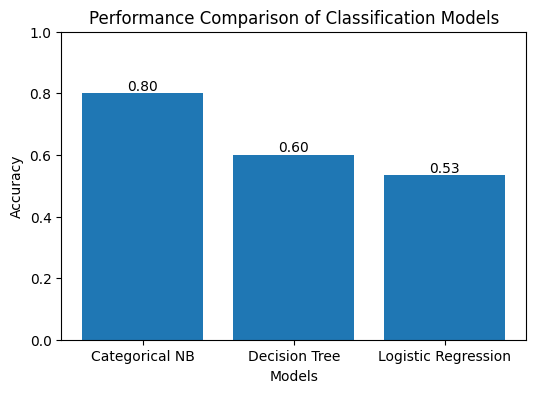

In [18]:
import matplotlib.pyplot as plt

# Model names
models = ['Categorical NB', 'Decision Tree', 'Logistic Regression']

# Accuracy values
accuracy = [0.80, 0.60, 0.5333]

# Create bar chart
plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracy)

# Add values on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01,
             f'{y:.2f}', ha='center')

plt.title('Performance Comparison of Classification Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)

plt.show()

Interpretation:

When compared with Decision Tree and Logistic Regression, Categorical Naive Bayes achieved the best performance for this dataset with an accuracy of 80%. The prediction for the new weather condition was generated successfully along with its probability which shows that Categorical Naive Bayes was more suitable because the dataset contains categorical weather attributes allowing it to classify the data more accurately than the other two models.